<a href="https://colab.research.google.com/github/aehaf988/Pro1/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assumptions:
- channels are independent


In [21]:
#import and file paths
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Making our catalog and signature list readable in the code. As well as showing what our lists contain.

In [22]:
CATALOG_URL = ('https://raw.githubusercontent.com/aehaf988/Pro1/main/data/'
               'Breast_genomes_mutational_catalog_96_subs.txt')

catalog = pd.read_csv(CATALOG_URL, sep='\t', index_col=0, decimal=',')


# ---------- COSMIC GRCh37 reference ----------
COSMIC_URL = ('https://raw.githubusercontent.com/aehaf988/Pro1/main/data/'
              'COSMIC_v3.6_SBS_GRCh37.txt')

cosmic = pd.read_csv(COSMIC_URL, sep='\t', index_col=0)

print('Shape', catalog.shape) #119 samples
print('Total mutations:', int(catalog.values.sum()))
print('First mutation types:', list(catalog.index[:3]))
print('First samples:', list(catalog.columns[:3]))

print('Shape', cosmic.shape) #101 signatures
print('First mutation types:', list(cosmic.index[:3]))
print('First signatures:', list(cosmic.columns[:3]))


Shape (96, 119)
Total mutations: 647692
First mutation types: ['A[C>A]A', 'A[C>A]C', 'A[C>A]G']
First samples: ['PD3851a', 'PD3890a', 'PD3904a']
Shape (96, 101)
First mutation types: ['A[C>A]A', 'A[C>A]C', 'A[C>A]G']
First signatures: ['SBS1', 'SBS2', 'SBS3']


Definition and choosing one sample.

- We want to check the mutation count of specifically signature 3 in our breast cancer samples
- we choose a random sample from our catalog (we can change to whichever sample in our list)

In [23]:
def mean(values):
  total = 0
  for v in values:
    total += v
  return total / len(values)

def std(values):
  m = mean(values)
  total = 0
  for v in values:
    total += (v-m) ** 2
  return (total/len(values)) ** 0.5

#one sample is chosen
sbs3_name = cosmic.columns[2]
sbs3_counts = cosmic[sbs3_name].tolist()

sample_idx = 0
name = catalog.columns[sample_idx]
counts = catalog[name].tolist()
N = len(counts)
N_total = N
theta_hat = mean(counts)

sigma_curv = std(counts) / (N**0.5)

print(cosmic.shape)
print(cosmic.columns.tolist()[:10])
print("chosen column:", sbs3_name)
print("first 5 counts:", sbs3_counts[:5])
print("sum of column:", sum(sbs3_counts))


(96, 101)
['SBS1', 'SBS2', 'SBS3', 'SBS4', 'SBS5', 'SBS6', 'SBS7a', 'SBS7b', 'SBS7c', 'SBS7d']
chosen column: SBS3
first 5 counts: [0.020808323, 0.016506603, 0.0017507, 0.012204882, 0.019707883]
sum of column: 0.999999999


För att kolla vår slope?


In [24]:
#model + slope check
def slope_at(score, theta, h):
  return (score(theta+h) -score(theta-h)) / (2*h)



Forward simulation of the sample chosen in the beginning

In [32]:
# forward simulation: one sample
N_total = int(catalog.values.sum()) #total mutations in catalog

def simulate_sbs3(theta, N_total, rng=None):
  if rng== None:
    rng = np.random.default_rng()

  return rng.poisson(N_total*theta)


def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(k, theta):
    """p(x | theta) = theta^x e^(-theta) / x!"""
    lam = N_total * theta
    return lam ** k * math.exp(-lam) / factorial(k)
print(N_total)

#tror det är detta egentligen.... i'm hella confused
def poisson_log_pmf(k, lam):
  return k * math.log(lam) - lam - math.lgamma(k+1)

def NLL(theta, K_obs, N_total):
  lam = N_total * theta
  return -poisson_log_pmf(K_obs, lam)



647692


In [34]:
#fitting
def fit_sbs3(counts, sbs3):
  return sum(counts)
print(counts)

[29, 30, 7, 18, 12, 13, 7, 10, 38, 14, 61, 19, 12, 17, 19, 24, 27, 19, 20, 36, 9, 4, 5, 8, 21, 19, 5, 23, 11, 5, 4, 7, 39, 17, 50, 31, 3, 10, 8, 19, 7, 11, 13, 10, 2, 9, 7, 15, 36, 13, 4, 18, 6, 9, 2, 7, 24, 21, 42, 15, 9, 6, 8, 12, 9, 4, 10, 13, 5, 2, 13, 10, 34, 30, 4, 32, 13, 15, 1, 27, 51, 43, 40, 41, 16, 9, 11, 14, 19, 6, 10, 13, 5, 4, 7, 14]


Backwards simulation by estimating theta the models parameter by adjusting the model to the published data


**Plot a:** distribution of a signature across samples


theta_hat    = 16.2604
sigma_curv   = 1.2738
SBS3 Poisson LL = -928.43 LR vs saturated = 1439.1 z = 97.5
theta_hat = 16.260 (mean count per mutation type)
theta_sbs3 = 1561 (total under SBS3 model)


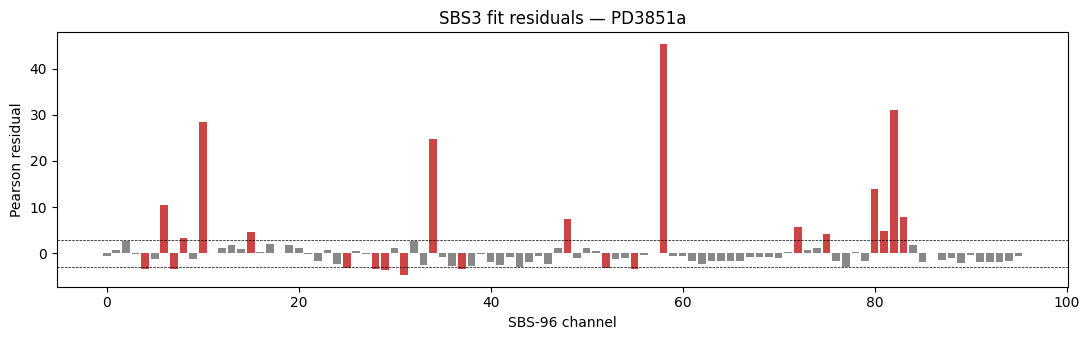

In [28]:
#backwards simulation
print(f"{'theta_hat':<12} = {theta_hat:.4f}")
print(f"{'sigma_curv':<12} = {sigma_curv:.4f}")

theta_sbs3 = sum(counts)                                # MLE of total under SBS3
lams  = [theta_sbs3 * p for p in sbs3_counts]            # expected counts under SBS3
ll_sbs3 = sum(poisson_log_pmf(k, lam) for k, lam in zip(counts, lams))
ll_sat  = sum(poisson_log_pmf(k, k)   for k in counts)
LR      = 2 * (ll_sat - ll_sbs3)
df = N-1
z = (LR - df) / math.sqrt(2*df)
print(f"SBS3 Poisson LL = {ll_sbs3:.2f} LR vs saturated = {LR:.1f} z = {z:.1f}")
print(f"theta_hat = {theta_hat:.3f} (mean count per mutation type)")
print(f"theta_sbs3 = {theta_sbs3:.0f} (total under SBS3 model)")
#A single-rate Poisson model underestimates the spread by ~3× because SBS-96 mutation counts are strongly overdispersed — each mutation type
# has its own rate. A per-type Poisson (or a multinomial) would be required for the likelihood approach to match the bootstrap

resid  = (np.array(counts) - lams) / np.sqrt(lams)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(range(96), resid, color=['#c44' if abs(r) > 3 else '#888' for r in resid])
ax.axhline( 3, color='k', lw=0.5, ls='--'); ax.axhline(-3, color='k', lw=0.5, ls='--')
ax.set_xlabel("SBS-96 channel"); ax.set_ylabel("Pearson residual")
ax.set_title(f"SBS3 fit residuals — {name}")
plt.tight_layout(); plt.show()

(non)parametric bootstrap for one sample (our backwards simulation).

---
**Plot b:** observed vs fitted spectrum for one sample

sample = PD3851a
N = 96
counts[:5] = [29, 30, 7, 18, 12]
min/max = 1 / 61
theta_mle   = 16.260 sigma_pooled = 0.412
theta_boot  = 16.283 sigma_boot   = 1.268
theta_hat   = 16.260
sigma_curv  = 1.274  (distribution-free)
sigma_boot  = 1.268  (resampling)
sigma_pool  = 0.412  (single-rate Poisson)
overdispersion ratio = 3.10x


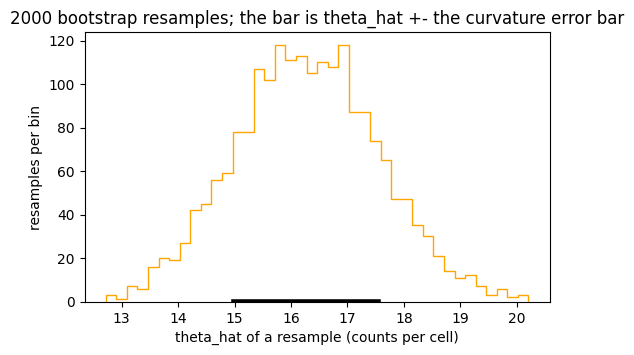

In [29]:
# uncertainty: parametric bootstrap for one sample

K_total = sum(counts)
N_total = N
theta_mle = K_total / N_total
sigma_pooled = math.sqrt(theta_hat / N)

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def choose(r, probs):
  running = 0.0
  for k in range(len(probs)):
    running = running + probs[k]
    if r < running:
      return k
  return len(probs) - 1

B = 2000 #resamples
SEED = 8
rs = uniforms(B * N, SEED) #every draw the bootstrap needs, '40' per sample
equal = [1/N] * N

boot_estimates = [0.0] * B
for b in range(B):
  resample = N * [0.0]
  for i in range(N):
    j = choose(rs[b * N + i], equal)
    resample[i] = counts[j]
  boot_estimates[b] = mean(resample)

sigma_boot = std(boot_estimates) #nonparametric bootstrap

print(f'sample = {name}')
print("N =", N)
print("counts[:5] =", counts[:5])
print("min/max =", min(counts),'/', max(counts))

print(f"theta_mle   = {theta_mle:.3f} sigma_pooled = {sigma_pooled:.3f}")
print(f"theta_boot  = {mean(boot_estimates):.3f} sigma_boot   = {sigma_boot:.3f}")

print(f"theta_hat   = {theta_hat:.3f}")
print(f"sigma_curv  = {sigma_curv:.3f}  (distribution-free)")
print(f"sigma_boot  = {sigma_boot:.3f}  (resampling)")
print(f"sigma_pool  = {sigma_pooled:.3f}  (single-rate Poisson)")
print(f"overdispersion ratio = {sigma_curv / sigma_pooled:.2f}x")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(boot_estimates, bins=40, color="orange", histtype="step")
ax.plot([theta_hat - sigma_curv, theta_hat + sigma_curv], [0, 0], color="black", linewidth=4)
ax.set_xlabel("theta_hat of a resample (counts per cell)")
ax.set_ylabel("resamples per bin")
ax.set_title("2000 bootstrap resamples; the bar is theta_hat +- the curvature error bar")
plt.show()


The model fails since MLE standard error differs too much (0.41)from the bootstrap and sample standard error at 1.27. This is because neither of them assumes a distribution. The overdistribution however reflects real biology with how different trinucleotides can mutation at different rates.

OVERDISPERSION

sigma_curv = std/sqrt(N) : how much would the average move if I re-ran the sequencing

sigma_boot = resampling: how much does the average move, using only the observed spread

sigma_pooled = single-rate poisson: how much would the average move if every mutation type had the same rate

1.27/ 0.41 = approximately 3 times smaller than the empirical standard error due to overdispersion.